In [ ]:
from pathlib import Path

# --------------------
# Configuration
# --------------------
INPUT_PATH = Path("../data/DroneDetect/DroneDetectV2_byModel/PHA/CLEAN__PHA_ON__PHA_0000_00.dat")  # <-- set this to your file
FS        = 60e6        # input sample rate (Hz)
DS_FS     = 20e6         # downsampled output sample rate (Hz)
DTYPE     = "float32"     # 'int16' or 'float32'
ENDIAN    = "little"    # 'little' or 'big'
IQ_ORDER  = "iq"        # 'iq' or 'qi'
SCALE_I16 = True        # scale int16 to [-1, 1)

TARGET_SAMPLES = 112320
ENERGY_THRESHOLD = 0.95 # for BW estimator
NFFT      = 2048           # if 0, use next power of 2 per chunk
LP_MARGIN = 1.2         # cutoff ≈ (BW/2)*LP_MARGIN
FILT_ORDER = 6          # IIR order when SciPy is available

PLOTS_DIR = Path("./plots")     # folder for saved images
PLOT_LIMIT = 3                  # how many chunks to plot (keeps output manageable)
OUT_DAT   = Path("./downsampled_5MHz.dat")  # output complex64 IQ at DS_FS

PLOTS_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
import math, json
import numpy as np
import matplotlib.pyplot as plt

# Try to import SciPy. If not available, fallback paths will be used.
try:
    from scipy.signal import butter, sosfiltfilt, resample_poly
    SCIPY_AVAILABLE = True
except Exception as _e:
    butter = sosfiltfilt = resample_poly = None
    SCIPY_AVAILABLE = False

import torch

print("SciPy available:", SCIPY_AVAILABLE)

SciPy available: True


In [3]:
# --------------------
# Utilities
# --------------------

def next_pow2(n: int) -> int:
    """Return next power-of-two >= n."""
    if n <= 1:
        return 1
    return 1 << (int(n - 1).bit_length())

def rational_resample_factors(fs_in: float, fs_out: float, max_den: int = 1000):
    """Prefer pure decimation when fs_in is an integer multiple of fs_out; otherwise a simple rational."""
    from fractions import Fraction
    if fs_in <= 0 or fs_out <= 0:
        raise ValueError("Sample rates must be positive.")
    if abs((fs_in / fs_out) - round(fs_in / fs_out)) < 1e-9:
        return 1, int(round(fs_in / fs_out))
    frac = Fraction(fs_out / fs_in).limit_denominator(max_den)
    return frac.numerator, frac.denominator

def complex_iq_reader(path: Path, dtype: str, endianness: str, chunk_iq: int, iq_order: str = "iq", scale: bool = True):
    """Yield complex64 chunks from an interleaved IQ .dat file."""
    if dtype not in ("int16", "float32"):
        raise ValueError("dtype must be 'int16' or 'float32'")
    if endianness not in ("little", "big"):
        raise ValueError("endianness must be 'little' or 'big'")
    if iq_order not in ("iq", "qi"):
        raise ValueError("iq_order must be 'iq' or 'qi'")

    dmap = {
        ("int16", "little"): "<i2",
        ("int16", "big"):    ">i2",
        ("float32", "little"): "<f4",
        ("float32", "big"):    ">f4",
    }
    dt = np.dtype(dmap[(dtype, endianness)])
    bps = dt.itemsize
    scalars_per_chunk = chunk_iq * 2

    with path.open("rb") as f:
        while True:
            buf = f.read(scalars_per_chunk * bps)
            if not buf:
                break
            arr = np.frombuffer(buf, dtype=dt)
            if arr.size < 2:
                break
            if arr.size % 2 == 1:
                arr = arr[:-1]
            I = arr[0::2] if iq_order == "iq" else arr[1::2]
            Q = arr[1::2] if iq_order == "iq" else arr[0::2]
            z = I.astype(np.float32) + 1j * Q.astype(np.float32)
            if dtype == "int16" and scale:
                z /= 32768.0
            yield z.astype(np.complex64, copy=False)

def mix_frequency(x: np.ndarray, fs: float, f_shift: float, start_idx: int = 0) -> np.ndarray:
    """Complex mix by f_shift (Hz). Positive f_shift moves spectrum up."""
    n = np.arange(x.size, dtype=np.float64) + float(start_idx)
    phase = np.exp(1j * 2.0 * np.pi * f_shift * (n / fs))
    return (x * phase.astype(np.complex64)).astype(np.complex64)

def design_fir_lowpass(cutoff_norm: float, numtaps: int = 129) -> np.ndarray:
    """Windowed-sinc FIR lowpass. cutoff_norm in cycles/sample (0..0.5)."""
    cutoff_norm = float(max(min(cutoff_norm, 0.499), 1e-4))
    M = numtaps - 1
    n = np.arange(numtaps, dtype=np.float64)
    h = 2.0 * cutoff_norm * np.sinc(2.0 * cutoff_norm * (n - M / 2.0))
    w = np.hamming(numtaps)
    h = h * w
    h = h / np.sum(h)
    return h.astype(np.float32)

def filtfilt_fir(x: np.ndarray, h: np.ndarray) -> np.ndarray:
    """Approximate zero-phase FIR filtering by forward-backward with 'same' length."""
    y = np.convolve(x, h, mode="same")
    y2 = np.convolve(y[::-1], h, mode="same")[::-1]
    return y2.astype(np.complex64)

def lowpass_dc(x: np.ndarray, fs: float, half_bw: float, iir_order: int):
    """Lowpass a DC-centered complex signal to approximately half_bw Hz."""
    norm_cut = min(max(half_bw / (fs * 0.5), 1e-4), 0.99)
    if SCIPY_AVAILABLE:
        sos = butter(N=iir_order, Wn=norm_cut, btype="low", output="sos")
        return sosfiltfilt(sos, x).astype(np.complex64)
    # FIR fallback
    taps = 129 if iir_order <= 6 else 255
    h = design_fir_lowpass(norm_cut * 0.98, numtaps=taps)  # slight margin
    return filtfilt_fir(x, h)

def resample_poly_fallback(x: np.ndarray, fs_in: float, fs_out: float):
    """Fallback for downsampling when SciPy isn't available and up==1."""
    up, down = rational_resample_factors(fs_in, fs_out)
    if up != 1:
        raise RuntimeError("SciPy not available and up != 1; please install SciPy for general rational resampling.")
    # FIR decimate by 'down' with anti-alias
    cutoff = 0.45 / down  # cycles/sample at input rate
    taps = 127 if down <= 8 else 255
    h = design_fir_lowpass(cutoff, numtaps=taps)
    y = np.convolve(x, h, mode="same")
    return y[::down].astype(np.complex64)

def plot_or_save_spectrogram(x: np.ndarray, fs: float, title: str, save_path=None, nfft: int = 4096, noverlap: int = 2048, show_inline=True):
    """Compute a complex-capable spectrogram (NumPy) and either display or save it (or both)."""
    x = np.asarray(x)
    N = x.size
    if N == 0:
        return
    hop = max(1, nfft - noverlap)
    if N < nfft:
        # zero-pad a single frame
        pad = nfft - N
        frames = np.pad(x, (0, pad), mode="constant")[None, :]
    else:
        n_frames = 1 + (N - nfft) // hop
        idx = np.arange(nfft)[None, :] + hop * np.arange(n_frames)[:, None]
        frames = x[idx]

    # Hann window
    w = np.hanning(nfft).astype(np.float32)
    frames = frames * w[None, :]

    # FFT and power
    S = np.fft.fftshift(np.fft.fft(frames, n=nfft, axis=1), axes=1)
    P = np.abs(S) ** 2 + 1e-12
    P_db = 10.0 * np.log10(P)

    # Axes
    times = (np.arange(frames.shape[0]) * hop) / fs
    freqs = np.linspace(-fs/2, fs/2, nfft, endpoint=False)

    fig = plt.figure(figsize=(9, 4.5))
    extent=(times[0], times[-1] if times.size>0 else 0, freqs[0], freqs[-1])
    plt.imshow(P_db.T, origin="lower", aspect="auto", extent=extent)
    plt.title(title)
    plt.xlabel("Time [s]")
    plt.ylabel("Frequency [Hz]")
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path)
    if show_inline:
        plt.show()
    else:
        plt.close(fig)

In [4]:
from typing import Optional, Tuple
from pathlib import Path
from __future__ import annotations
# ---------- RAW PSD helpers (no SciPy) ----------
def _welch_psd_signed_np(sig: np.ndarray, fs: float, nperseg: int = 4096, noverlap: int = 2048):
    """
    Welch-style PSD for real or complex signals, returning signed freqs (Hz) and PSD (linear).
    Pure NumPy. Uses Hann windows and averages segments.
    """
    x = np.asarray(sig)
    N = x.size
    step = nperseg - noverlap
    if step <= 0:
        raise ValueError("noverlap must be < nperseg")
    if N < nperseg:
        pad = np.zeros(nperseg, dtype=x.dtype)
        pad[:N] = x
        x = pad
        N = nperseg

    w = np.hanning(nperseg).astype(np.float32)
    denom = (np.sum(w**2) * fs)

    acc = None
    segs = 0
    for s in range(0, N - nperseg + 1, step):
        seg = x[s:s+nperseg]
        seg = seg - np.mean(seg)
        X = np.fft.fft(w * seg, n=nperseg)
        P = (np.abs(X)**2) / denom
        acc = P if acc is None else (acc + P)
        segs += 1
    if segs == 0:
        X = np.fft.fft(w * x[:nperseg], n=nperseg)
        acc = (np.abs(X)**2) / denom
        segs = 1

    Pavg = acc / segs
    f = np.fft.fftfreq(nperseg, d=1/fs)
    return np.fft.fftshift(f), np.fft.fftshift(Pavg)

def plot_psd_with_threshold(sig: np.ndarray,
                            fs: float,
                            *,
                            band_hz: Optional[Tuple[float, float]] = None,
                            threshold_db: Optional[float] = None,
                            rel_db_below_peak: float = 10.0,
                            nperseg: Optional[int] = None,
                            noverlap=(int(NFFT) if int(NFFT) > 0 else 4096)//2,  
                            title: str = "PSD + threshold",
                            save_path: Optional[Path] = None,
                            show_inline: bool = False) -> float:
    """
    Make a PSD plot of 'sig' at sample rate 'fs', draw threshold and detected CF.
    Returns detected center frequency (signed baseband Hz, peak above threshold within band if given).
    """
    # Pick segment size: use your NFFT if set, else default
    nseg = int(NFFT) if (isinstance(NFFT, (int, float)) and int(NFFT) > 0) else (nperseg or 4096)
    f, P = _welch_psd_signed_np(sig, fs, nperseg=nseg, noverlap=noverlap)
    P_db = 10.0 * np.log10(P + 1e-20)

    if band_hz is not None:
        flo, fhi = float(band_hz[0]), float(band_hz[1])
        band_mask = (f >= flo) & (f <= fhi)
    else:
        band_mask = np.ones_like(f, dtype=bool)

    peak_db_in_band = np.max(P_db[band_mask]) if np.any(band_mask) else np.max(P_db)
    thr_db = (peak_db_in_band - float(rel_db_below_peak)) if threshold_db is None else float(threshold_db)

    cand_mask = band_mask & (P_db >= thr_db)
    if np.any(cand_mask):
        k = np.argmax(P[cand_mask])
        f0 = f[np.flatnonzero(cand_mask)[k]]
    else:
        f0 = f[np.argmax(P)]

    if show_inline:
        fig = plt.figure(figsize=(8.5, 4.0))
        plt.plot(f/1e6, P_db)
        if band_hz is not None:
            plt.axvspan(flo/1e6, fhi/1e6, alpha=0.15)
        plt.axhline(thr_db, linestyle="--")
        plt.axvline(f0/1e6, linestyle=":")
        plt.title(title)
        plt.xlabel("Frequency (MHz)")
        plt.ylabel("PSD (dB/Hz)")
        fig.tight_layout()
        if save_path is not None:
            fig.savefig(save_path)
        if show_inline:
            plt.show()
        else:
            plt.close(fig)

        print(f"[PSD] {title}: peak_in_band≈{peak_db_in_band:.1f} dB/Hz, thr={thr_db:.1f} dB/Hz, CF={f0/1e6:.6f} MHz")
    return float(f0)

In [6]:
# --------------------
#  Energy Estimator 
# --------------------
from dataclasses import dataclass
from typing import Tuple

@dataclass
class Estimator:
    sample_freq: float

    def estimate_bandwidth_and_center(self, x: torch.Tensor, nfft: int, energy_threshold: float = 0.95) -> Tuple[torch.Tensor, torch.Tensor]:
        """Estimate bandwidth and center frequency of each sample in the batch (exactly your function)."""
        fft_x = torch.fft.fft(x, n=nfft, dim=-1, norm='ortho')
        power = torch.abs(fft_x) ** 2  # [batch, nfft]
        total_power = torch.sum(power, dim=-1, keepdim=True)  # [batch, 1]

        # Bandwidth: number of bins containing 95% energy
        sorted_power, _indices = torch.sort(power, dim=-1, descending=True)
        cumsum_power = torch.cumsum(sorted_power, dim=-1) / total_power  # [batch, nfft]
        energy_threshold_tensor = torch.full((cumsum_power.shape[0],), energy_threshold, device=x.device)
        num_bins = torch.searchsorted(cumsum_power, energy_threshold_tensor[:, None], right=True).squeeze(-1)  # [batch]
        freq_resolution = self.sample_freq / nfft
        bandwidths = num_bins * freq_resolution
        bandwidths = torch.clamp(bandwidths, min=10e3, max=self.sample_freq / 2)

        # Center frequency: weighted average of frequencies within bandwidth
        k = torch.arange(nfft, device=x.device)
        freqs = k * (self.sample_freq / nfft)
        freqs[k >= nfft // 2] -= self.sample_freq  # [-Fs/2, Fs/2]
        power_normalized = power / total_power  # [batch, nfft]
        center_freqs = torch.sum(power_normalized * freqs, dim=-1)  # [batch]
        return bandwidths, center_freqs

In [5]:
def detect_cf_bw_from_psd(sig: np.ndarray,
                          fs: float,
                          *,
                          band_hz: Optional[Tuple[float,float]] = None,
                          threshold_db: Optional[float] = None,
                          rel_db_below_peak: float = 10.0,
                          nperseg: Optional[int] = None,
                          noverlap: Optional[int] = None,
                          dc_notch_hz: float = 0.0
                          ) -> Tuple[float, float, float, float, float]:
    """
    Peak-centered, contiguous-above-threshold detector.
    Returns (cf_hz, bw_hz, thr_db, f_lo, f_hi).

    - band_hz: restrict detection to this freq window (Hz), else full band
    - threshold_db: absolute dB/Hz threshold; if None, uses peak - rel_db_below_peak
    - dc_notch_hz: exclude |f| < dc_notch_hz from detection (avoid LO/DC)
    """
    # pick segment size/overlap using your globals
    nseg = int(NFFT) if (isinstance(NFFT, (int, float)) and int(NFFT) > 0) else (nperseg or 4096)
    if noverlap is None:
        noverlap = max(1, nseg // 2)

    f, P = _welch_psd_signed_np(sig, fs, nperseg=nseg, noverlap=noverlap)
    P_db = 10.0 * np.log10(P + 1e-20)

    # build mask
    mask = np.ones_like(f, dtype=bool)
    if band_hz is not None:
        flo, fhi = float(band_hz[0]), float(band_hz[1])
        mask &= (f >= flo) & (f <= fhi)
    if dc_notch_hz and dc_notch_hz > 0:
        mask &= (np.abs(f) >= dc_notch_hz)

    # peak and threshold
    if not np.any(mask):
        # fallback: global
        k0 = int(np.argmax(P))
        f0 = float(f[k0])
        return f0, 0.0, float(P_db[k0]), f0, f0

    band_db = P_db[mask]
    band_f  = f[mask]
    k0_rel  = int(np.argmax(band_db))
    peak_db = float(band_db[k0_rel])
    thr_db  = float(peak_db - rel_db_below_peak) if threshold_db is None else float(threshold_db)

    above = (band_db >= thr_db)
    if not np.any(above):
        f0 = float(band_f[k0_rel])
        return f0, 0.0, thr_db, f0, f0

    # walk left/right from peak while above threshold (contiguous slab)
    k_lo = k0_rel
    while k_lo - 1 >= 0 and above[k_lo - 1]:
        k_lo -= 1
    k_hi = k0_rel
    L = above.size
    while k_hi + 1 < L and above[k_hi + 1]:
        k_hi += 1

    f_lo = float(band_f[k_lo])
    f_pk = float(band_f[k0_rel])
    f_hi = float(band_f[k_hi])
    cf_hz = 0.5 * (f_lo + f_hi)
    bw_hz = max(0.0, f_hi - f_lo)

    return cf_hz, bw_hz, thr_db, f_lo, f_hi

In [6]:
def detect_cf_bw_abs_threshold(sig: np.ndarray,
                               fs: float,
                               *,
                               threshold_db: float = -110.0,      # absolute dB/Hz
                               band_hz: Optional[Tuple[float, float]] = None,
                               nperseg: Optional[int] = None,
                               noverlap: Optional[int] = None,
                               cf_zero_tol_hz: float = 1.0e5,      # “near 0” = |cf| < 100 kHz
                               min_bw_if_near_zero_hz: float = 2.0e5  # ignore if |cf|<tol AND bw<200 kHz
                               ) -> Optional[Tuple[float, float, float, float, float]]:
    """
    Absolute-threshold PSD detector.
    Returns (cf_hz, bw_hz, thr_db, f_lo, f_hi) or None if no valid slab.

    - threshold_db: fixed floor in dB/Hz (e.g., -110)
    - band_hz: optional (f_lo, f_hi) window to search
    - cf_zero_tol_hz & min_bw_if_near_zero_hz implement the “ignore near-DC & <200 kHz” rule
    """
    # segment sizing
    nseg = int(NFFT) if (isinstance(NFFT, (int, float)) and int(NFFT) > 0) else (nperseg or 4096)
    if noverlap is None:
        noverlap = max(1, nseg // 2)

    f, P = _welch_psd_signed_np(sig, fs, nperseg=nseg, noverlap=noverlap)
    P_db = 10.0 * np.log10(P + 1e-20)

    mask = np.ones_like(f, dtype=bool)
    if band_hz is not None:
        flo, fhi = float(band_hz[0]), float(band_hz[1])
        mask &= (f >= flo) & (f <= fhi)

    # bins above fixed threshold inside the search mask
    valid = mask & (P_db >= threshold_db)
    if not np.any(valid):
        return None

    # choose the peak within the valid set, then expand left/right while above threshold
    k_peak_valid = int(np.argmax(P[valid]))
    peak_indices = np.flatnonzero(valid)
    k0 = peak_indices[k_peak_valid]

    k_lo = k0
    while k_lo - 1 >= 0 and valid[k_lo - 1]:
        k_lo -= 1
    k_hi = k0
    L = len(f)
    while k_hi + 1 < L and valid[k_hi + 1]:
        k_hi += 1

    f_lo = float(f[k_lo])
    f_pk = float(f[k0])
    f_hi = float(f[k_hi])
    cf_hz = 0.5 * (f_lo + f_hi)
    bw_hz = max(0.0, f_hi - f_lo)

    # ignore “near 0 and <200 kHz wide”
    if abs(cf_hz) < cf_zero_tol_hz and bw_hz < min_bw_if_near_zero_hz:
        return None

    return cf_hz, bw_hz, float(threshold_db), f_lo, f_hi

In [7]:
def _slice_psd_detect(sig, fs, threshold_db=-110.0, nfft=2048):
    # One FFT slice → PSD(dB), peak index, CF/BW from contiguous-above-threshold region
    x = np.asarray(sig)
    w = np.hanning(nfft).astype(np.float32)
    X = np.fft.fft(w * x[:nfft], n=nfft)
    P = (np.abs(X)**2) / (np.sum(w**2) * fs)
    f = np.fft.fftfreq(nfft, d=1/fs)
    P = np.fft.fftshift(P); f = np.fft.fftshift(f)
    P_db = 10.0*np.log10(P + 1e-20)

    valid = (P_db >= threshold_db)
    if not np.any(valid):
        return False, 0.0, 0.0, 0.0, 0.0, f, P_db

    k0_rel = int(np.argmax(P_db))
    # expand contiguous region above threshold around peak
    k_lo = k0_rel
    while k_lo-1 >= 0 and valid[k_lo-1]: k_lo -= 1
    k_hi = k0_rel
    L = len(f)
    while k_hi+1 < L and valid[k_hi+1]: k_hi += 1

    f_lo, f_pk, f_hi = float(f[k_lo]), float(f[k0_rel]), float(f[k_hi])
    cf_hz = 0.5*(f_lo + f_hi)
    bw_hz = max(0.0, f_hi - f_lo)
    return True, cf_hz, bw_hz, f_lo, f_hi, f, P_db


In [8]:
def find_bursts_in_file(path: Path,
                        fs: float,
                        *,
                        dtype: str = DTYPE,
                        endianness: str = ENDIAN,
                        iq_order: str = IQ_ORDER,
                        threshold_db: float = -110.0,
                        nfft: int = 2048,
                        hop: int = 1024,
                        dc_cf_tol_hz: float = 1e5,      # |CF|<100 kHz is "near DC"
                        min_bw_if_near_dc_hz: float = 2e5,  # <200 kHz near DC → ignore
                        min_len_slices: int = 2,       # require ≥2 consecutive slices "active"
                        gap_slices: int = 1            # tolerate brief gaps inside a burst
                        ):
    """
    Returns a list of bursts: [(start_idx, end_idx, cf_hz, bw_hz), ...]
    start_idx/end_idx are sample indices at the RAW rate 'fs'.
    """
    bursts = []
    reader_chunk = max(8*nfft, 65536)  # IO chunk for the file reader
    rdr = complex_iq_reader(path, dtype, endianness, reader_chunk, iq_order, scale=(dtype=="int16"))

    # ring buffer large enough to slide with overlap
    buf = np.zeros(0, dtype=np.complex64)
    file_pos = 0               # absolute sample index of buf[0]
    active = False
    act_start = None           # absolute index of burst start
    act_last_ok_slice_end = None
    consec_ok = 0
    gap = 0
    cf_hold = 0.0
    bw_hold = 0.0

    def finish_burst():
        nonlocal active, act_start, consec_ok, gap, cf_hold, bw_hold, act_last_ok_slice_end
        if active and act_start is not None and act_last_ok_slice_end is not None and consec_ok >= min_len_slices:
            bursts.append((act_start, act_last_ok_slice_end, cf_hold, bw_hold))
        active = False
        act_start = None
        act_last_ok_slice_end = None
        consec_ok = 0
        gap = 0
        cf_hold = 0.0
        bw_hold = 0.0

    # streaming over file
    for z in rdr:
        # append new data
        if buf.size == 0:
            buf = z
        else:
            buf = np.concatenate((buf, z), axis=0)

        # slide windows while we have at least one new hop
        i = 0
        while i + nfft <= buf.size:
            sl = buf[i:i+nfft]
            ok, cf_hz, bw_hz, f_lo, f_hi, fvec, Pdb = _slice_psd_detect(sl, fs, threshold_db, nfft)

            # apply "ignore near DC skinny junk"
            if ok and (abs(cf_hz) < dc_cf_tol_hz and bw_hz < min_bw_if_near_dc_hz):
                ok = False

            slice_start_abs = file_pos + i
            slice_end_abs   = file_pos + i + nfft

            if ok:
                gap = 0
                consec_ok += 1
                act_last_ok_slice_end = slice_end_abs
                if not active:
                    active = True
                    act_start = slice_start_abs
                    cf_hold, bw_hold = cf_hz, bw_hz
                else:
                    # update CF/BW with a running average (stable across slices)
                    cf_hold = 0.8*cf_hold + 0.2*cf_hz
                    bw_hold = max(bw_hold, bw_hz)  # keep widest seen in burst
            else:
                if active:
                    gap += 1
                    if gap > gap_slices:
                        # end the burst
                        finish_burst()

            i += hop

        # drop what we consumed, keep the last nfft-hop overlap for next round
        keep_from = max(0, buf.size - (nfft - hop))
        file_pos += (buf.size - keep_from)
        buf = buf[keep_from:]

    # tail: finalize any active burst
    finish_burst()
    return bursts


In [9]:
bursts = find_bursts_in_file(
    INPUT_PATH, FS,
    threshold_db=-110.0,
    nfft=2048, hop=1024,            # 50% overlap
    dc_cf_tol_hz=1e5,               # near-DC if |CF|<100 kHz
    min_bw_if_near_dc_hz=2e5,       # drop if <200 kHz wide near DC
    min_len_slices=2, gap_slices=1  # need 2 consecutive “on” slices
)
print(f"found {len(bursts)} bursts")
for k,(s,e,cf,bw) in enumerate(bursts[:5]):
    dur = (e - s)/FS
    print(f"{k}: samples[{s}:{e}]  dur={dur*1e3:.2f} ms  cf={cf/1e6:.3f} MHz  bw={bw/1e6:.3f} MHz")


found 235 bursts
0: samples[3072:45056]  dur=0.70 ms  cf=0.461 MHz  bw=4.014 MHz
1: samples[39936:70656]  dur=0.51 ms  cf=2.476 MHz  bw=7.031 MHz
2: samples[84992:78848]  dur=-0.10 ms  cf=4.493 MHz  bw=5.566 MHz
3: samples[51200:78848]  dur=0.46 ms  cf=6.505 MHz  bw=2.871 MHz
4: samples[99328:101376]  dur=0.03 ms  cf=-15.493 MHz  bw=1.377 MHz


In [10]:
for (s, e, cf_hz, bw_hz) in bursts:
    # read that segment again (or keep a second pass with a bigger reader)
    # Here’s the simple way: load just that range from disk once you have offsets.
    # If you prefer streaming-only, you can restructure to cache slices; but this is clearest.

    # Quick re-read: iterate until we cover [s:e]
    seg = np.zeros(e - s, dtype=np.complex64)
    filled = 0
    rdr = complex_iq_reader(INPUT_PATH, DTYPE, ENDIAN, chunk_iq= max(8*2048, 65536), iq_order=IQ_ORDER, scale=(DTYPE=="int16"))
    acc = 0
    for z in rdr:
        zlen = z.size
        if acc + zlen <= s:
            acc += zlen; continue
        take_from = max(0, s - acc)
        take_to   = min(zlen, e - acc)
        if take_to > take_from:
            ncopy = take_to - take_from
            seg[filled:filled+ncopy] = z[take_from:take_to]
            filled += ncopy
            if filled >= seg.size:
                break
        acc += zlen

    # filter/shift/downsample using detected cf/bw
    mixed = mix_frequency(seg, FS, f_shift=-cf_hz, start_idx=s)
    half_bw = max(0.5*bw_hz*LP_MARGIN, 5e3)   # you already have LP_MARGIN
    lp = lowpass_dc(mixed, FS, half_bw, iir_order=FILT_ORDER)

    if SCIPY_AVAILABLE:
        up, down = rational_resample_factors(FS, DS_FS)
        y = resample_poly(lp, up, down).astype(np.complex64)
    else:
        y = resample_poly_fallback(lp, FS, DS_FS)

    # optional: plot a few
    # plot_or_save_spectrogram(y, DS_FS, f"burst at {cf_hz/1e6:.3f} MHz", save_path=PLOTS_DIR/f"burst_{s}_{e}.png")
    # then slice to your 37,440-sample frames as needed


ValueError: negative dimensions are not allowed

/tmp/ipykernel_274099/3602649271.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


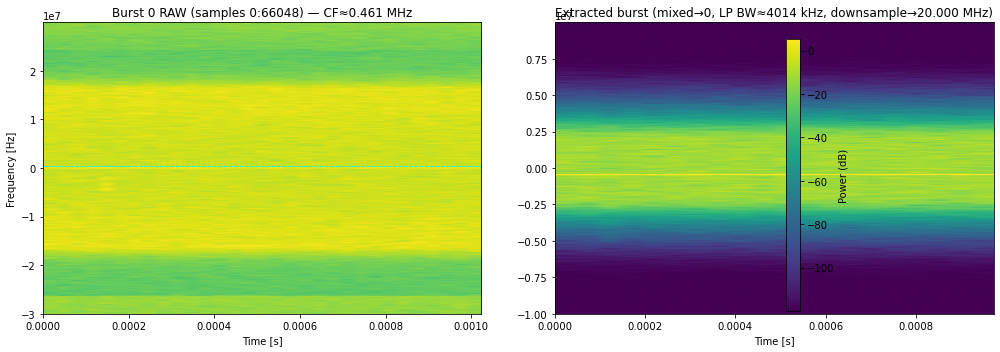

Saved comparison: plots/burst_00_raw_vs_extracted.png


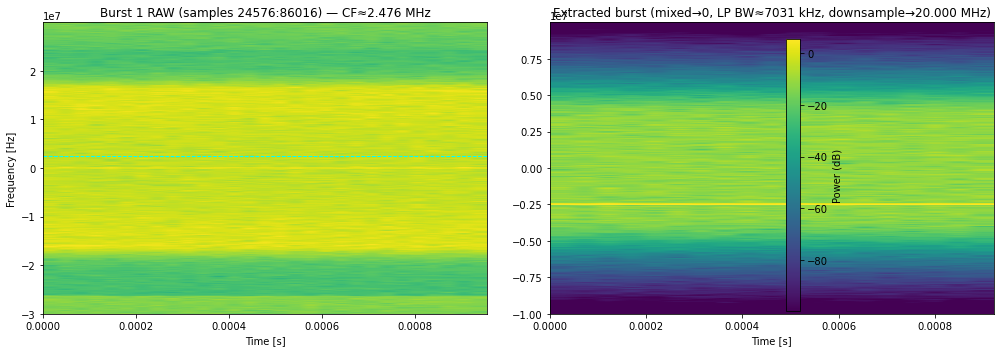

Saved comparison: plots/burst_01_raw_vs_extracted.png


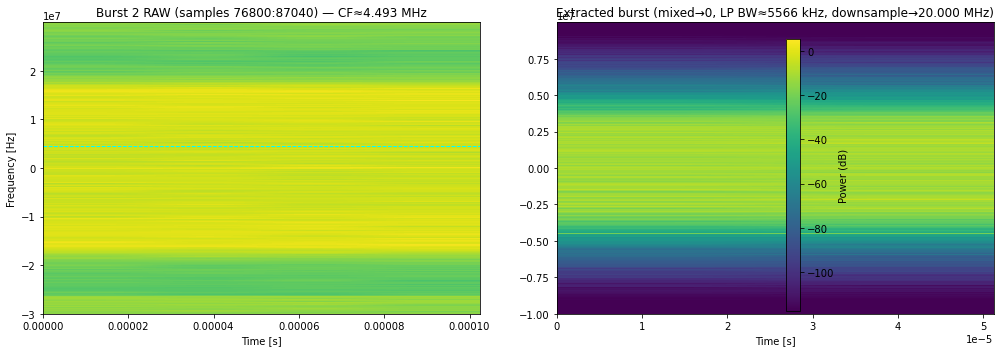

Saved comparison: plots/burst_02_raw_vs_extracted.png


In [ ]:
# Visual comparison: raw spectrogram vs extracted-burst spectrogram (placed in a new cell at index 11)
import matplotlib.pyplot as plt

def _compute_spectrogram(x: np.ndarray, fs: float, nfft: int = 4096, noverlap: int = None):
    x = np.asarray(x)
    if noverlap is None:
        noverlap = nfft // 2
    hop = max(1, nfft - noverlap)
    N = x.size
    if N < nfft:
        pad = nfft - N
        frames = np.pad(x, (0, pad), mode="constant")[None, :]
    else:
        n_frames = 1 + (N - nfft) // hop
        idx = np.arange(nfft)[None, :] + hop * np.arange(n_frames)[:, None]
        frames = x[idx]
    w = np.hanning(nfft).astype(np.float32)
    frames = frames * w[None, :]
    S = np.fft.fftshift(np.fft.fft(frames, n=nfft, axis=1), axes=1)
    P = np.abs(S) ** 2 + 1e-12
    P_db = 10.0 * np.log10(P)
    times = (np.arange(frames.shape[0]) * hop) / fs
    freqs = np.linspace(-fs/2, fs/2, nfft, endpoint=False)
    return P_db, times, freqs

if not bursts:
    print("No bursts detected to visualize.")
else:
    # plot up to first 3 bursts
    to_plot = bursts[:min(3, len(bursts))]
    for bi, (s, e, cf_hz, bw_hz) in enumerate(to_plot):
        # choose padding around burst for context
        nfft_spec_raw = 4096
        nfft_spec_ex = 2048
        pad = max(4 * (int(NFFT) if int(NFFT) > 0 else 2048), (e - s) // 2, 8192)
        start = max(0, int(s - pad))
        end = int(e + pad)

        # read interval [start:end] from disk
        seg = np.zeros(end - start, dtype=np.complex64)
        filled = 0
        rdr = complex_iq_reader(INPUT_PATH, DTYPE, ENDIAN, chunk_iq=max(8*2048, 65536), iq_order=IQ_ORDER, scale=(DTYPE=="int16"))
        acc = 0
        for z in rdr:
            zlen = z.size
            if acc + zlen <= start:
                acc += zlen; continue
            take_from = max(0, start - acc)
            take_to   = min(zlen, end - acc)
            if take_to > take_from:
                ncopy = take_to - take_from
                seg[filled:filled+ncopy] = z[take_from:take_to]
                filled += ncopy
                if filled >= seg.size:
                    break
            acc += zlen
        if filled < seg.size:
            seg = seg[:filled]

        # raw spectrogram (at input rate)
        P_raw_db, t_raw, f_raw = _compute_spectrogram(seg, FS, nfft=nfft_spec_raw, noverlap=nfft_spec_raw//2)

        # extract burst: mix to DC, lowpass around half BW, downsample
        mixed = mix_frequency(seg, FS, f_shift=-cf_hz, start_idx=start)
        half_bw = max(0.5 * bw_hz * LP_MARGIN, 5e3)
        lp = lowpass_dc(mixed, FS, half_bw, iir_order=FILT_ORDER)
        if SCIPY_AVAILABLE:
            up, down = rational_resample_factors(FS, DS_FS)
            baseband_ds = resample_poly(lp, up, down).astype(np.complex64)
            ds_fs = DS_FS
        else:
            baseband_ds = resample_poly_fallback(lp, FS, DS_FS)
            ds_fs = DS_FS

        P_ex_db, t_ex, f_ex = _compute_spectrogram(baseband_ds, ds_fs, nfft=nfft_spec_ex, noverlap=nfft_spec_ex//2)

        # common color scale (use percentiles to avoid extreme outliers)
        combined = np.concatenate([P_raw_db.ravel(), P_ex_db.ravel()])
        vmin = float(np.percentile(combined, 2.0))
        vmax = float(np.percentile(combined, 98.0))

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
        im1 = ax1.imshow(P_raw_db.T, origin="lower", aspect="auto",
                         extent=(t_raw[0] if t_raw.size>0 else 0, t_raw[-1] if t_raw.size>0 else 0, f_raw[0], f_raw[-1]),
                         vmin=vmin, vmax=vmax)
        ax1.set_title(f"Burst {bi} RAW (samples {start}:{end}) — CF≈{cf_hz/1e6:.3f} MHz")
        ax1.set_xlabel("Time [s]")
        ax1.set_ylabel("Frequency [Hz]")
        # mark detected CF on raw spectrogram
        ax1.axhline(cf_hz, color="cyan", linestyle="--", linewidth=1)

        im2 = ax2.imshow(P_ex_db.T, origin="lower", aspect="auto",
                         extent=(t_ex[0] if t_ex.size>0 else 0, t_ex[-1] if t_ex.size>0 else 0, f_ex[0], f_ex[-1]),
                         vmin=vmin, vmax=vmax)
        ax2.set_title(f"Extracted burst (mixed→0, LP BW≈{bw_hz/1e3:.0f} kHz, downsample→{ds_fs/1e6:.3f} MHz)")
        ax2.set_xlabel("Time [s]")

        fig.colorbar(im1, ax=[ax1, ax2], label="Power (dB)")
        fig.tight_layout()
        outpath = PLOTS_DIR / f"burst_{bi:02d}_raw_vs_extracted.png"
        fig.savefig(outpath)
        plt.show()
        plt.close(fig)
        print(f"Saved comparison: {outpath}")
        

Burst 0: read samples [0:53248]  detected CF=0.461 MHz  BW=4.014 MHz
Saved: plots/verify_burst_00_raw_vs_extracted.png


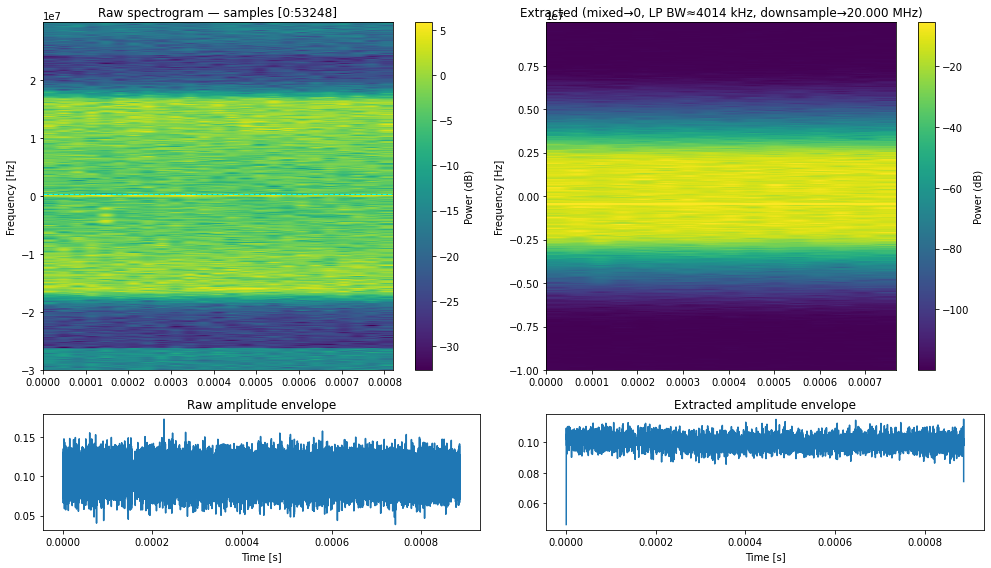

In [12]:
from math import ceil

# Quick verification plot: raw segment vs extracted (mixed→DC, lowpass, downsample)
# Uses existing utilities in this notebook (complex_iq_reader, mix_frequency, lowpass_dc, resample_poly, _compute_spectrogram)

import matplotlib.pyplot as plt

def plot_raw_and_extracted(burst_idx: int = 0, padding_samples: int = 4096, save: bool = True):
    if not bursts:
        print("No bursts detected.")
        return

    # clamp index
    burst_idx = max(0, min(burst_idx, len(bursts) - 1))
    s, e, cf_hz, bw_hz = bursts[burst_idx]
    start = max(0, int(s - padding_samples))
    end = int(e + padding_samples)
    print(f"Burst {burst_idx}: read samples [{start}:{end}]  detected CF={cf_hz/1e6:.3f} MHz  BW={bw_hz/1e6:.3f} MHz")

    # read raw samples for interval [start:end]
    seg = np.zeros(end - start, dtype=np.complex64)
    filled = 0
    acc = 0
    rdr = complex_iq_reader(INPUT_PATH, DTYPE, ENDIAN, chunk_iq=max(8*2048, 65536), iq_order=IQ_ORDER, scale=(DTYPE=="int16"))
    for z in rdr:
        zlen = z.size
        if acc + zlen <= start:
            acc += zlen
            continue
        take_from = max(0, start - acc)
        take_to = min(zlen, end - acc)
        if take_to > take_from:
            ncopy = take_to - take_from
            seg[filled:filled+ncopy] = z[take_from:take_to]
            filled += ncopy
            if filled >= seg.size:
                break
        acc += zlen
    if filled < seg.size:
        seg = seg[:filled]
        end = start + filled
        print(f"Warning: reached EOF early; clipped to [{start}:{end}]")

    # Raw spectrogram and envelope
    P_raw_db, t_raw, f_raw = _compute_spectrogram(seg, FS, nfft=4096, noverlap=2048)
    env_raw = np.abs(seg)

    # Extracted: mix to DC, LP around half BW (with margin), downsample
    mixed = mix_frequency(seg, FS, f_shift=-cf_hz, start_idx=start)
    half_bw = max(0.5 * bw_hz * LP_MARGIN, 5e3)
    lp = lowpass_dc(mixed, FS, half_bw, iir_order=FILT_ORDER)
    if SCIPY_AVAILABLE:
        up, down = rational_resample_factors(FS, DS_FS)
        baseband_ds = resample_poly(lp, up, down).astype(np.complex64)
        ds_fs = DS_FS
    else:
        baseband_ds = resample_poly_fallback(lp, FS, DS_FS)
        ds_fs = DS_FS

    P_ex_db, t_ex, f_ex = _compute_spectrogram(baseband_ds, ds_fs, nfft=2048, noverlap=1024)
    env_ex = np.abs(baseband_ds)

    # Plot: top row spectrograms, bottom row envelopes (time aligned)
    fig, axes = plt.subplots(2, 2, figsize=(14, 8), gridspec_kw={"height_ratios": [3, 1]})
    # RAW spectrogram
    im0 = axes[0,0].imshow(P_raw_db.T, origin="lower", aspect="auto",
                           extent=(t_raw[0] if t_raw.size>0 else 0, t_raw[-1] if t_raw.size>0 else 0, f_raw[0], f_raw[-1]),
                           vmin=np.percentile(P_raw_db,2), vmax=np.percentile(P_raw_db,98))
    axes[0,0].set_title(f"Raw spectrogram — samples [{start}:{end}]")
    axes[0,0].set_ylabel("Frequency [Hz]")
    # mark detected CF on raw (absolute frequency)
    axes[0,0].axhline(cf_hz, color="cyan", linestyle="--", linewidth=1)

    # Extracted spectrogram
    im1 = axes[0,1].imshow(P_ex_db.T, origin="lower", aspect="auto",
                           extent=(t_ex[0] if t_ex.size>0 else 0, t_ex[-1] if t_ex.size>0 else 0, f_ex[0], f_ex[-1]),
                           vmin=np.percentile(P_ex_db,2), vmax=np.percentile(P_ex_db,98))
    axes[0,1].set_title(f"Extracted (mixed→0, LP BW≈{bw_hz/1e3:.0f} kHz, downsample→{ds_fs/1e6:.3f} MHz)")
    axes[0,1].set_ylabel("Frequency [Hz]")

    # Time axis for envelopes: map raw samples to seconds
    time_raw = np.arange(seg.size) / FS
    axes[1,0].plot(time_raw, env_raw)
    axes[1,0].set_title("Raw amplitude envelope")
    axes[1,0].set_xlabel("Time [s]")
    # For extracted, create its time axis
    time_ex = np.arange(baseband_ds.size) / ds_fs
    axes[1,1].plot(time_ex, env_ex)
    axes[1,1].set_title("Extracted amplitude envelope")
    axes[1,1].set_xlabel("Time [s]")

    fig.colorbar(im0, ax=axes[0,0], label="Power (dB)")
    fig.colorbar(im1, ax=axes[0,1], label="Power (dB)")
    fig.tight_layout()

    if save:
        outp = PLOTS_DIR / f"verify_burst_{burst_idx:02d}_raw_vs_extracted.png"
        fig.savefig(outp)
        print(f"Saved: {outp}")

    plt.show()
    plt.close(fig)

# Example: plot the first detected burst (change index if you want)
plot_raw_and_extracted(burst_idx=0, padding_samples=8192, save=True)

In [18]:
# --------------------
# Per-chunk processing
# --------------------
from typing import Optional, Tuple

def process_chunk(
    z_chunk: np.ndarray,
    fs: float,
    est: Estimator,
    energy_threshold: float,
    nfft_opt: Optional[int],
    lp_margin: float,
    filt_order: int,
    outdir: Path,
    idx: int,
    plot_this_chunk: bool,
    start_idx: int,
    ds_fs: float
) -> Tuple[np.ndarray, float, float]:
    # Torch estimation
    det = detect_cf_bw_abs_threshold(
    z_chunk, fs,
    threshold_db=-110.0,
    band_hz=(-fs/2, fs/2),      # or tighten later; e.g., (-fs/2, -2e6) to exclude DC area
    cf_zero_tol_hz=1.0e5,       # “near zero” within ±100 kHz
    min_bw_if_near_zero_hz=2.0e5
)

    if det is None:
    # no acceptable slab found; choose your policy:
    # 1) skip this chunk:
    # return np.array([], dtype=np.complex64), 0.0, 0.0
    # 2) or fall back to your Torch estimator:
        bw_hz = 0
        cf_hz = 0
    else:
        cf_hz, bw_hz, thr_db, f_lo, f_hi = det

    # BEFORE
    if plot_this_chunk:
        plot_or_save_spectrogram(z_chunk, fs, f"Chunk {idx} — BEFORE filtering",
                                 save_path=outdir / f"chunk{idx:04d}_01_before.png")
        
        # Example search band: left half of spectrum; adjust as you prefer
    raw_band = (-FS/2, FS/2)  # or e.g., (-15e6, -3e6)
    x_for_psd = z_chunk - np.mean(z_chunk)  # complex mean
    f0_raw = plot_psd_with_threshold(
        z_chunk, fs,
        band_hz=raw_band,
        rel_db_below_peak=8.0,     # raise/lower to tighten/loosen detection
        title=f"Chunk {idx} — RAW PSD + threshold",
        save_path=outdir / f"chunk{idx:04d}_00_raw_psd.png",
        show_inline=False
        )

    # Mix to DC
    mixed_to_dc = mix_frequency(z_chunk, fs, f_shift=-cf_hz, start_idx=start_idx)

    # Lowpass around BW/2 with margin
    half_bw = max(bw_hz * 0.5 * lp_margin, 5e3)
    lp_at_dc = lowpass_dc(mixed_to_dc, fs, half_bw, iir_order=filt_order)

    # Mix back for the "after band-pass" view
    mixed_back = mix_frequency(lp_at_dc, fs, f_shift=cf_hz, start_idx=start_idx)

    if plot_this_chunk:
        plot_or_save_spectrogram(mixed_back, fs,
                                 f"Chunk {idx} — AFTER band-pass (BW≈{bw_hz/1e6:.3f} MHz, CF≈{cf_hz/1e6:.3f} MHz)",
                                 save_path=outdir / f"chunk{idx:04d}_02_after_bp.png")
    
    
    f0_bp = plot_psd_with_threshold(
        mixed_back, fs,
        band_hz=None,               # full band, or narrow if you want
        rel_db_below_peak=8.0,
        title=f"Chunk {idx} — BP (pre-shift) PSD + threshold",
        save_path=outdir / f"chunk{idx:04d}_02b_bp_psd.png",
        show_inline=False)

    # Shift to 0 and downsample
    if SCIPY_AVAILABLE:
        up, down = rational_resample_factors(fs, ds_fs)
        baseband_ds = resample_poly(lp_at_dc, up, down).astype(np.complex64)
    else:
        baseband_ds = resample_poly_fallback(lp_at_dc, fs, ds_fs)

    if plot_this_chunk:
        plot_or_save_spectrogram(baseband_ds, ds_fs,
                                 f"Chunk {idx} — AFTER shift→0 & downsample to {ds_fs/1e6:.3f} MHz",
                                 save_path=outdir / f"chunk{idx:04d}_03_after_shift_ds.png")

    return baseband_ds, bw_hz, cf_hz

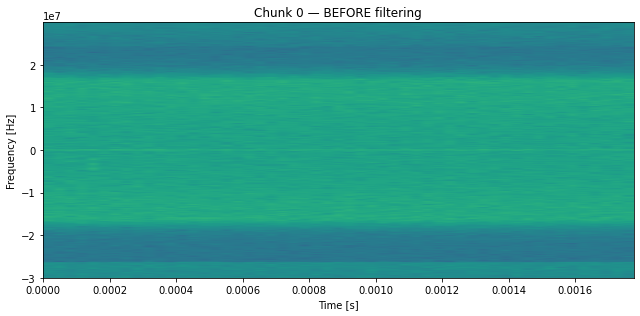

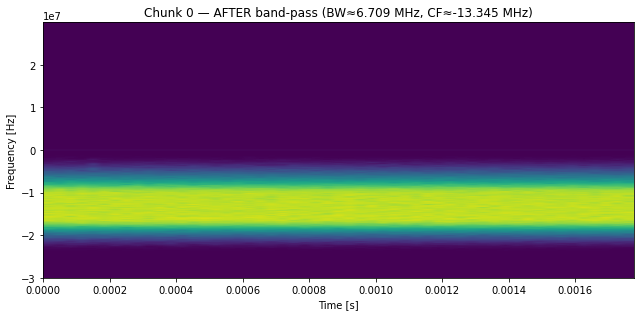

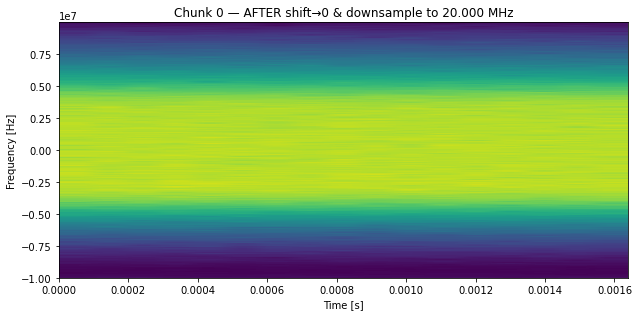

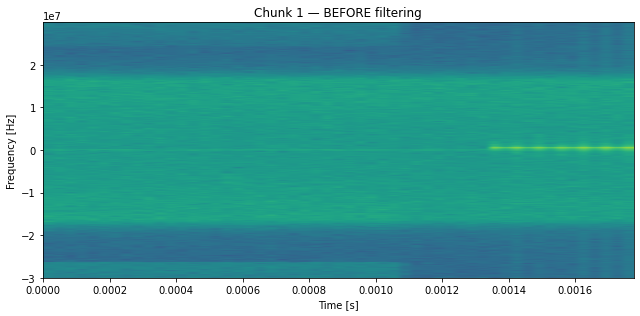

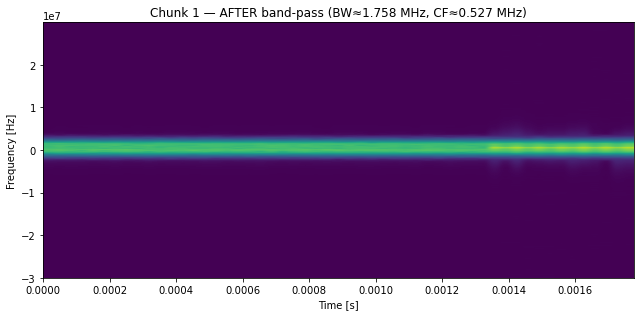

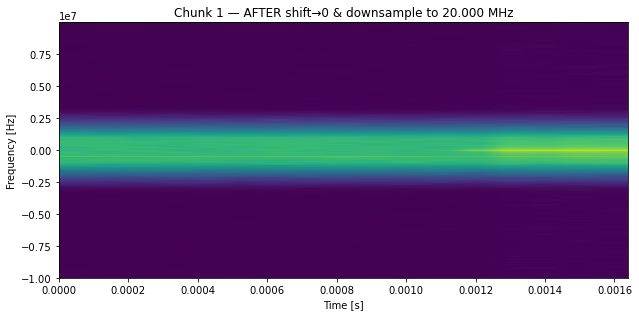

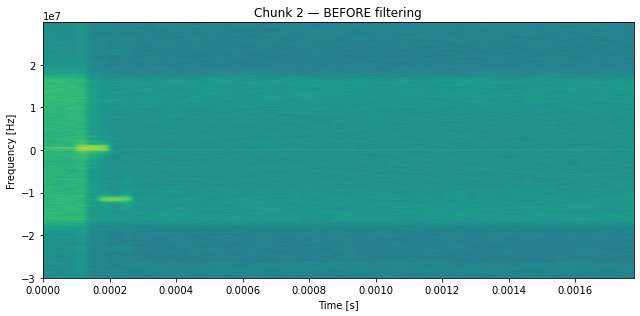

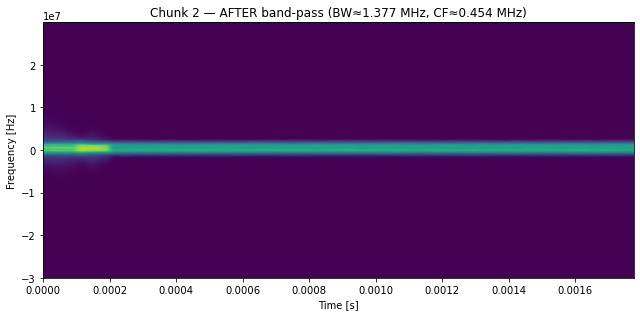

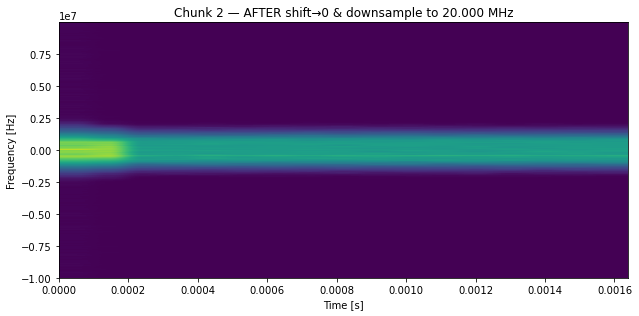

Done. Plots in: plots
Downsampled IQ written to: downsampled_5MHz.dat
Summary JSON: plots/summary.json


In [21]:
# --------------------
# Run the pipeline
# --------------------
assert INPUT_PATH.exists(), f"INPUT_PATH not found: {INPUT_PATH}"
chunk_iq = int(TARGET_SAMPLES)

est = Estimator(sample_freq=FS)
reader = complex_iq_reader(
    path=INPUT_PATH,
    dtype=DTYPE,
    endianness=ENDIAN,
    chunk_iq=chunk_iq,
    iq_order=IQ_ORDER,
    scale=SCALE_I16 if DTYPE == "int16" else False,
)

nfft_opt = None if NFFT == 0 else int(NFFT)
plotted = 0
total_in = 0
total_out = 0
chunk_idx = 0
start_idx = 0

summary = []
with OUT_DAT.open("wb") as out_f:
    for z_chunk in reader:
        if z_chunk.size == 0:
            break

        plot_this = plotted < max(0, int(PLOT_LIMIT))

        y_ds, bw_hz, cf_hz = process_chunk(
            z_chunk=z_chunk,
            fs=FS,
            est=est,
            energy_threshold=ENERGY_THRESHOLD,
            nfft_opt=nfft_opt,
            lp_margin=LP_MARGIN,
            filt_order=FILT_ORDER,
            outdir=PLOTS_DIR,
            idx=chunk_idx,
            plot_this_chunk=plot_this,
            start_idx=start_idx,
            ds_fs=DS_FS
        )

        # Write downsampled chunk as complex64
        y_ds.astype(np.complex64).tofile(out_f)

        summary.append({
            "chunk": int(chunk_idx),
            "in_samples": int(z_chunk.size),
            "out_samples": int(y_ds.size),
            "bw_hz": float(bw_hz),
            "center_hz": float(cf_hz),
        })

        total_in += z_chunk.size
        total_out += y_ds.size
        chunk_idx += 1
        start_idx += z_chunk.size

        if plot_this:
            plotted += 1

# Save summary JSON
summary_path = PLOTS_DIR / "summary.json"
with summary_path.open("w") as jf:
    json.dump({
        "input": str(INPUT_PATH),
        "fs_hz": float(FS),
        "downsampled_fs_hz": float(DS_FS),
        "total_in_samples": int(total_in),
        "total_out_samples": int(total_out),
        "chunks": summary
    }, jf, indent=2)

print(f"Done. Plots in: {PLOTS_DIR}")
print(f"Downsampled IQ written to: {OUT_DAT}")
print(f"Summary JSON: {summary_path}")